Descargando datos...
Datos: 6538 velas | 2000-01-03 -> 2025-12-30
Corriendo backtest...

RESULTADOS FINALES — RSI(2)<20 + ATR x0.3 + Trail 0.5%
SPY 2000-2025 | Capital inicial: USD 100,000

RETORNO:
  Retorno total     : 7153.6%
  CAGR              : 17.9%
  Capital final     : USD 7,253,567

RIESGO:
  Sharpe ratio      : 1.70
  Max Drawdown      : -11.7%
  Calmar ratio      : 1.53

TRADES:
  Total trades      : 862
  Win rate          : 55.2%
  Trades/año        : 33
  Duracion promedio : 1.5 dias
  Salidas por Stop  : 211 (24%)
  Salidas por Trail : 651 (76%)
  Expectancy        : USD 8,299 por trade

COMPARACION BUY & HOLD SPY:
  METRICA                  ESTRATEGIA   BUY & HOLD
  ------------------------------------------------
  Retorno total                7153.6%        680.4%
  CAGR                           17.9%          8.2%
  Sharpe                         1.70         0.51
  Max Drawdown                  -11.7%        -55.2%
  Calmar                         1.53         0.1

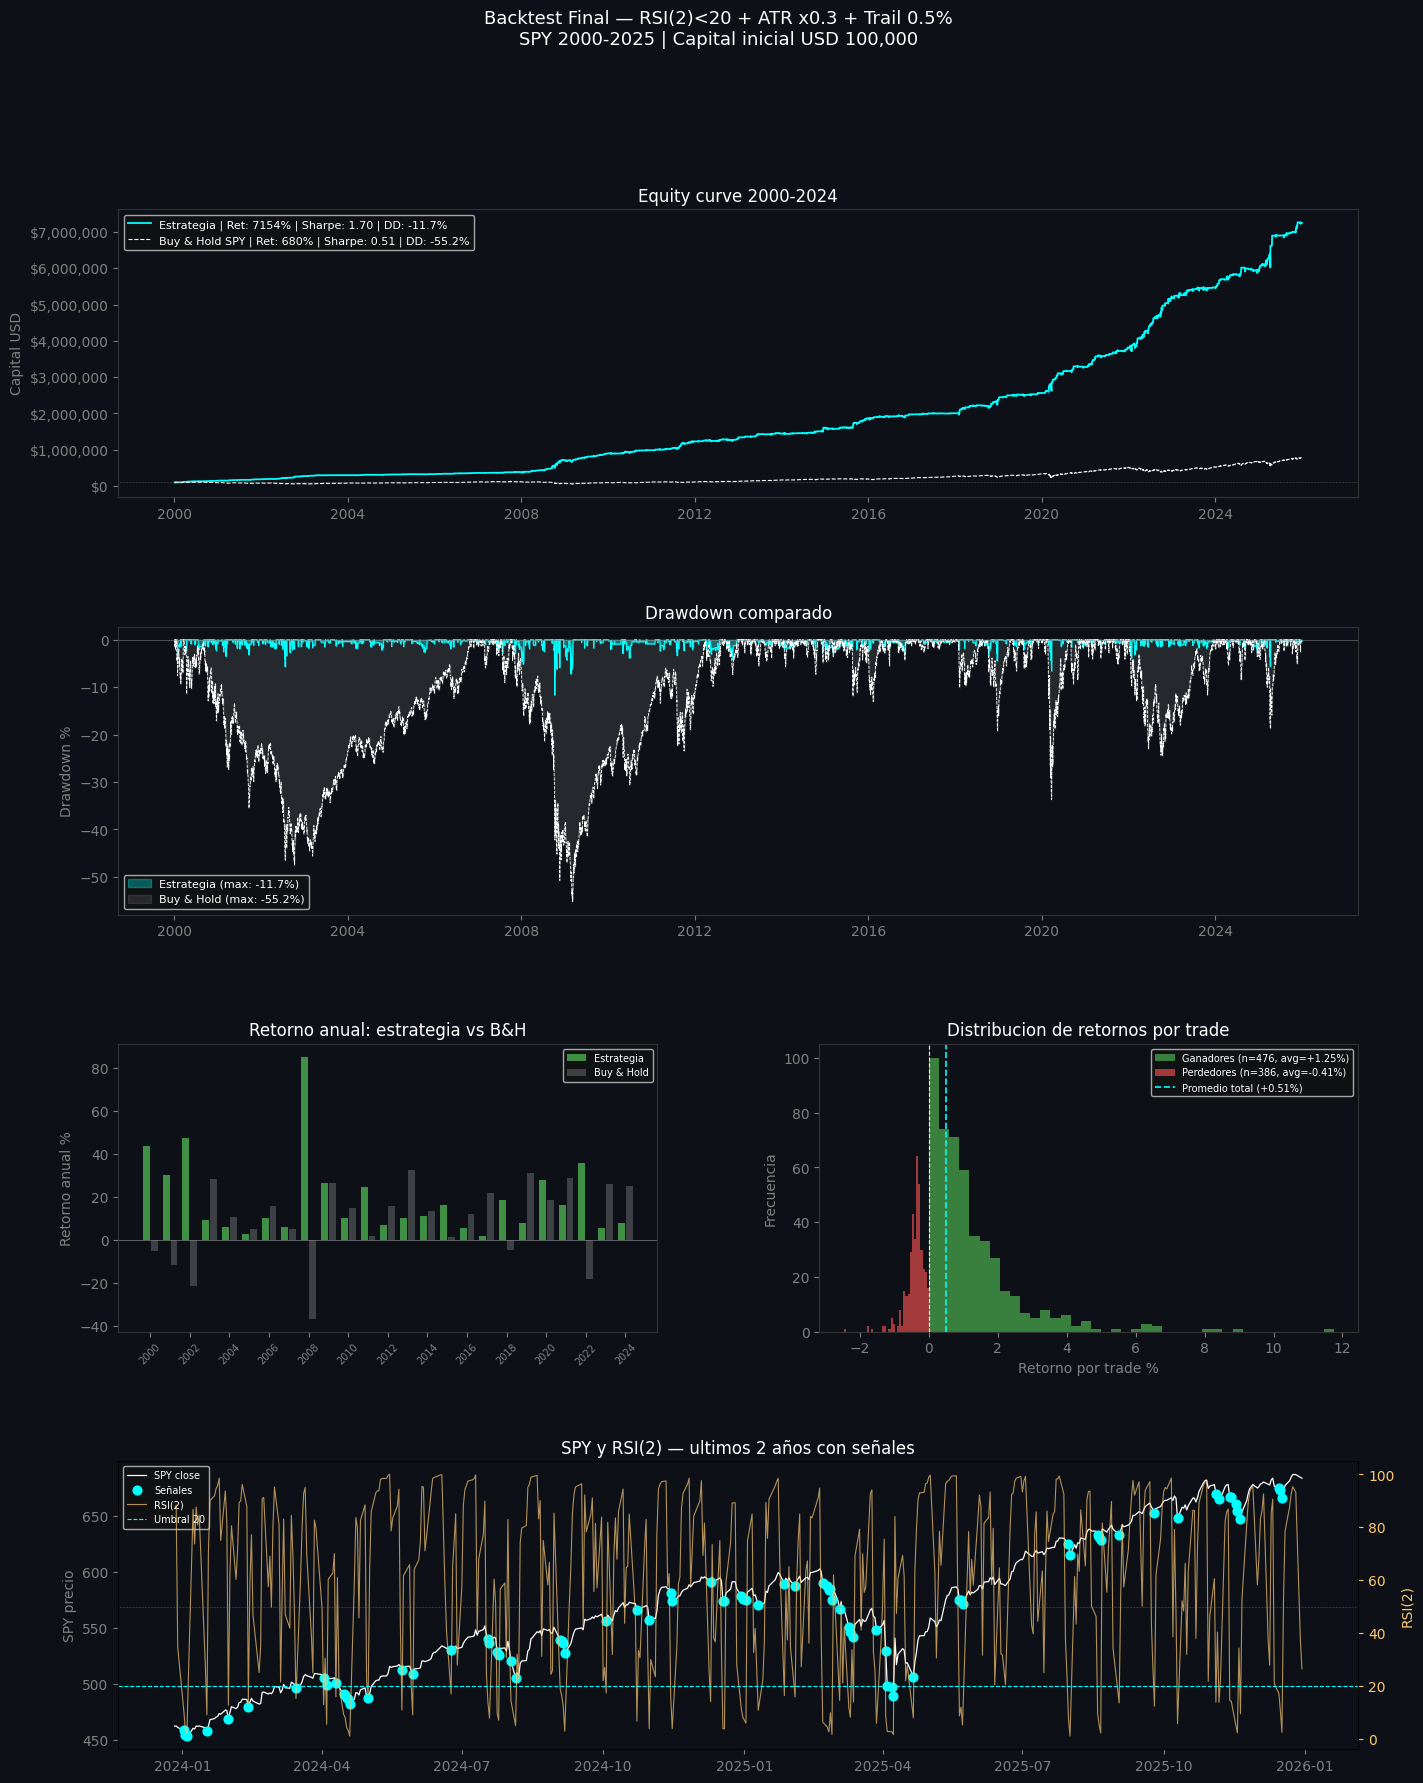


Grafico guardado como backtest_final.png

Fin del backtest.


In [3]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ══════════════════════════════════════════════════════════════
# ESTRATEGIA FINAL — RSI(2)<20 + ATR x0.30 + Trailing 0.5%
# SPY 2000-2024
# ══════════════════════════════════════════════════════════════

# ── PARAMETROS ───────────────────────────────────────────────
TICKER      = "SPY"
START       = "2000-01-01"
END         = "2025-12-31"
INITIAL_CAP = 100000.0
RSI_PERIOD  = 2
RSI_ENTRY   = 20
ATR_PERIOD  = 14
ATR_MULT    = 0.30
TRAIL_PCT   = 0.50     # trailing stop 0.5% desde el maximo
COMMISSION  = 1.0      # USD por lado
SLIPPAGE    = 0.05     # % de slippage

# ── DESCARGA ─────────────────────────────────────────────────
print("Descargando datos...")
raw = yf.download(TICKER, start=START, end=END,
                  interval="1d", auto_adjust=True, progress=False)
raw.columns = raw.columns.get_level_values(0)
df = raw[["Open","High","Low","Close"]].copy()
df.columns = ["open","high","low","close"]
df = df.dropna()
print(f"Datos: {len(df)} velas | {df.index[0].date()} -> {df.index[-1].date()}")

# ── INDICADORES ───────────────────────────────────────────────
delta    = df["close"].diff()
gain     = delta.clip(lower=0)
loss     = -delta.clip(upper=0)
avg_gain = gain.ewm(alpha=1/RSI_PERIOD, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/RSI_PERIOD, adjust=False).mean()
rs        = avg_gain / avg_loss
df["rsi"] = 100 - (100 / (1 + rs))

df["tr"] = np.maximum(
    df["high"] - df["low"],
    np.maximum(
        abs(df["high"] - df["close"].shift(1)),
        abs(df["low"]  - df["close"].shift(1))
    )
)
df["atr"]          = df["tr"].ewm(span=ATR_PERIOD, adjust=False).mean()
df["entry_signal"] = (df["rsi"] < RSI_ENTRY).astype(int)
df = df.dropna()

# ── BACKTEST ─────────────────────────────────────────────────
def backtest_trailing(data, trail_pct, commission=1.0,
                       slippage_pct=0.05, initial_cap=100000.0):
    position     = 0
    entry_price  = 0.0
    stop_init    = 0.0
    trail_stop   = 0.0
    max_price    = 0.0
    trail_activo = False
    entry_date   = None
    shares       = 0
    cash         = float(initial_cap)
    trades       = []
    equity       = []

    for i in range(1, len(data)):
        bar  = data.iloc[i]
        prev = data.iloc[i - 1]
        date = data.index[i]

        # ENTRADA
        if position == 0 and prev["entry_signal"] == 1:
            raw_px       = float(bar["open"])
            entry_price  = raw_px * (1 + slippage_pct / 100)
            shares       = int(cash // entry_price)
            if shares == 0:
                equity.append(cash)
                continue
            cash        -= shares * entry_price + commission
            stop_init    = entry_price - ATR_MULT * float(prev["atr"])
            trail_stop   = stop_init
            max_price    = entry_price
            trail_activo = False
            entry_date   = date
            position     = 1

        # GESTION Y SALIDA
        elif position == 1:
            curr_high = float(bar["high"])
            curr_low  = float(bar["low"])

            # Actualizar maximo y trailing stop
            if curr_high > max_price:
                max_price = curr_high

            # El trailing se activa solo cuando el precio supera la entrada
            if max_price > entry_price:
                trail_activo = True
                nuevo_trail  = max_price * (1 - trail_pct / 100)
                trail_stop   = max(trail_stop, nuevo_trail)
            else:
                trail_stop = stop_init

            # Verificar si se toca el stop
            if curr_low <= trail_stop:
                exit_price  = trail_stop * (1 - slippage_pct / 100)
                exit_reason = "Trail" if trail_activo else "Stop"
                cash       += shares * exit_price - commission
                pnl         = shares * (exit_price - entry_price) - 2 * commission
                dur         = (date - entry_date).days if entry_date else 0
                trades.append({
                    "entrada"  : entry_date,
                    "salida"   : date,
                    "duracion" : dur,
                    "ret_pct"  : (exit_price / entry_price - 1) * 100,
                    "pnl"      : round(pnl, 2),
                    "razon"    : exit_reason,
                    "entry_px" : round(entry_price, 2),
                    "exit_px"  : round(exit_price, 2),
                })
                position = 0
                shares   = 0

        equity.append(cash + shares * float(bar["close"]))

    eq  = pd.Series(equity, index=data.index[1:len(equity)+1])
    tdf = pd.DataFrame(trades)
    return eq, tdf

# ── CORRER BACKTEST ───────────────────────────────────────────
print("Corriendo backtest...")
eq, tdf = backtest_trailing(df, TRAIL_PCT, COMMISSION, SLIPPAGE, INITIAL_CAP)

# ── METRICAS ─────────────────────────────────────────────────
n      = len(tdf)
wr     = (tdf["pnl"] > 0).mean() * 100
ret    = (eq.iloc[-1] / INITIAL_CAP - 1) * 100
years  = (eq.index[-1] - eq.index[0]).days / 365.25
cagr   = ((eq.iloc[-1] / INITIAL_CAP) ** (1 / years) - 1) * 100
dd     = (eq - eq.cummax()) / eq.cummax() * 100
max_dd = dd.min()
dr     = eq.pct_change().dropna()
sharpe = (dr.mean() / dr.std()) * np.sqrt(252)
wins   = tdf[tdf["pnl"] > 0]["pnl"]
losses = tdf[tdf["pnl"] <= 0]["pnl"]
avg_w  = wins.mean()   if len(wins)   > 0 else 0
avg_l  = losses.mean() if len(losses) > 0 else 0
exp    = (wr/100 * avg_w) + ((1 - wr/100) * avg_l)
calmar = abs(cagr / max_dd) if max_dd != 0 else 0
stops  = len(tdf[tdf["razon"] == "Stop"])
trails = len(tdf[tdf["razon"] == "Trail"])
avg_dur= tdf["duracion"].mean()

# Buy & Hold referencia
bh_eq  = df["close"] / df["close"].iloc[0] * INITIAL_CAP
bh_ret = (bh_eq.iloc[-1] / INITIAL_CAP - 1) * 100
bh_dd  = ((bh_eq - bh_eq.cummax()) / bh_eq.cummax() * 100).min()
bh_dr  = bh_eq.pct_change().dropna()
bh_sh  = (bh_dr.mean() / bh_dr.std()) * np.sqrt(252)
bh_cagr= ((bh_eq.iloc[-1] / INITIAL_CAP) ** (1/years) - 1) * 100

# ── RESULTADOS ────────────────────────────────────────────────
print(f"""
{'='*55}
RESULTADOS FINALES — RSI(2)<{RSI_ENTRY} + ATR x{ATR_MULT} + Trail {TRAIL_PCT}%
SPY {START[:4]}-{END[:4]} | Capital inicial: USD {INITIAL_CAP:,.0f}
{'='*55}

RETORNO:
  Retorno total     : {ret:.1f}%
  CAGR              : {cagr:.1f}%
  Capital final     : USD {eq.iloc[-1]:,.0f}

RIESGO:
  Sharpe ratio      : {sharpe:.2f}
  Max Drawdown      : {max_dd:.1f}%
  Calmar ratio      : {calmar:.2f}

TRADES:
  Total trades      : {n}
  Win rate          : {wr:.1f}%
  Trades/año        : {n/years:.0f}
  Duracion promedio : {avg_dur:.1f} dias
  Salidas por Stop  : {stops} ({stops/n*100:.0f}%)
  Salidas por Trail : {trails} ({trails/n*100:.0f}%)
  Expectancy        : USD {exp:,.0f} por trade

COMPARACION BUY & HOLD SPY:
  {'METRICA':<22} {'ESTRATEGIA':>12} {'BUY & HOLD':>12}
  {'-'*48}
  {'Retorno total':<22} {ret:>12.1f}% {bh_ret:>12.1f}%
  {'CAGR':<22} {cagr:>12.1f}% {bh_cagr:>12.1f}%
  {'Sharpe':<22} {sharpe:>12.2f} {bh_sh:>12.2f}
  {'Max Drawdown':<22} {max_dd:>12.1f}% {bh_dd:>12.1f}%
  {'Calmar':<22} {calmar:>12.2f} {abs(bh_cagr/bh_dd):>12.2f}
{'='*55}
""")

# ── RENDIMIENTO ANUAL ─────────────────────────────────────────
print("RENDIMIENTO ANUAL:")
print(f"  {'Año':>5} {'Ret Estrat%':>12} {'Ret BH%':>10} {'Trades':>7} {'DD%':>8}")
print(f"  {'-'*47}")
for year in range(2000, 2025):
    mask_eq = eq.index.year == year
    mask_bh = bh_eq.index.year == year
    mask_tr = (tdf["entrada"].dt.year == year) if "entrada" in tdf.columns else []
    if mask_eq.sum() == 0:
        continue
    eq_y  = eq[mask_eq]
    bh_y  = bh_eq[mask_bh]
    cap_i = eq[eq.index.year < year].iloc[-1] if (eq.index.year < year).any() else INITIAL_CAP
    ret_y = (eq_y.iloc[-1] / cap_i - 1) * 100 if cap_i > 0 else 0
    bh_i  = bh_eq[bh_eq.index.year < year].iloc[-1] if (bh_eq.index.year < year).any() else INITIAL_CAP
    bh_y_ret = (bh_y.iloc[-1] / bh_i - 1) * 100 if bh_i > 0 else 0
    dd_y  = ((eq_y - eq_y.cummax()) / eq_y.cummax() * 100).min()
    n_y   = len(tdf[tdf["entrada"].dt.year == year]) if "entrada" in tdf.columns and len(tdf) > 0 else 0
    marker= " *" if ret_y < 0 else ""
    print(f"  {year:>5} {ret_y:>12.1f} {bh_y_ret:>10.1f} {n_y:>7} {dd_y:>8.1f}{marker}")

# ── ULTIMOS 20 TRADES ─────────────────────────────────────────
print(f"\nULTIMOS 20 TRADES:")
print(f"  {'Entrada':<12} {'Salida':<12} {'Dur':>4} "
      f"{'Entry':>8} {'Exit':>8} {'Ret%':>7} {'PnL USD':>9} {'Razon':<8}")
print(f"  {'-'*72}")
for _, row in tdf.tail(20).iterrows():
    ent_s = row["entrada"].strftime("%Y-%m-%d") if pd.notna(row.get("entrada")) else "?"
    sal_s = row["salida"].strftime("%Y-%m-%d")  if pd.notna(row.get("salida"))  else "?"
    pnl_c = "+" if row["pnl"] >= 0 else ""
    print(f"  {ent_s:<12} {sal_s:<12} {row['duracion']:>4.0f}d "
          f"{row['entry_px']:>8.2f} {row['exit_px']:>8.2f} "
          f"{row['ret_pct']:>+7.3f} {pnl_c}{row['pnl']:>8.0f} {row['razon']:<8}")

# ── GRAFICOS ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 20))
fig.patch.set_facecolor("#0d1117")
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)
fig.suptitle(
    f"Backtest Final — RSI(2)<{RSI_ENTRY} + ATR x{ATR_MULT} + Trail {TRAIL_PCT}%\n"
    f"SPY {START[:4]}-{END[:4]} | Capital inicial USD {INITIAL_CAP:,.0f}",
    fontsize=13, color="white"
)

# 1: Equity curve principal
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor("#0d1117")
ax1.plot(eq.index,    eq,    color="cyan",    lw=1.3,
         label=f"Estrategia | Ret: {ret:.0f}% | Sharpe: {sharpe:.2f} | DD: {max_dd:.1f}%")
ax1.plot(bh_eq.index, bh_eq, color="white",  lw=0.8, ls="--",
         label=f"Buy & Hold SPY | Ret: {bh_ret:.0f}% | Sharpe: {bh_sh:.2f} | DD: {bh_dd:.1f}%")
ax1.axhline(y=INITIAL_CAP, color="gray", lw=0.4, ls=":")
ax1.set_ylabel("Capital USD", color="gray")
ax1.tick_params(colors="gray")
ax1.spines[:].set_color("#333")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.legend(fontsize=8, facecolor="#111", labelcolor="white")
ax1.set_title("Equity curve 2000-2024", color="white")

# 2: Drawdown
ax2 = fig.add_subplot(gs[1, :])
ax2.set_facecolor("#0d1117")
dd_bh = (bh_eq - bh_eq.cummax()) / bh_eq.cummax() * 100
ax2.fill_between(dd.index,    dd,    0, color="cyan",  alpha=0.3,
                  label=f"Estrategia (max: {max_dd:.1f}%)")
ax2.fill_between(dd_bh.index, dd_bh, 0, color="white", alpha=0.1,
                  label=f"Buy & Hold (max: {bh_dd:.1f}%)")
ax2.plot(dd.index,    dd,    color="cyan",  lw=0.8)
ax2.plot(dd_bh.index, dd_bh, color="white", lw=0.6, ls="--")
ax2.axhline(y=0, color="gray", lw=0.4)
ax2.set_ylabel("Drawdown %", color="gray")
ax2.tick_params(colors="gray")
ax2.spines[:].set_color("#333")
ax2.legend(fontsize=8, facecolor="#111", labelcolor="white")
ax2.set_title("Drawdown comparado", color="white")

# 3: Retorno anual barras
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor("#0d1117")
años_list  = []
rets_e_list= []
rets_b_list= []
for year in range(2000, 2025):
    mask = eq.index.year == year
    if mask.sum() == 0:
        continue
    eq_y = eq[mask]
    bh_y = bh_eq[bh_eq.index.year == year]
    cap_i= eq[eq.index.year < year].iloc[-1] if (eq.index.year < year).any() else INITIAL_CAP
    bh_i = bh_eq[bh_eq.index.year < year].iloc[-1] if (bh_eq.index.year < year).any() else INITIAL_CAP
    años_list.append(year)
    rets_e_list.append((eq_y.iloc[-1] / cap_i - 1) * 100 if cap_i > 0 else 0)
    rets_b_list.append((bh_y.iloc[-1] / bh_i - 1) * 100 if bh_i > 0 else 0)

x = np.arange(len(años_list))
ax3.bar(x - 0.2, rets_e_list, 0.35,
        color=["#4CAF50" if v >= 0 else "#E24B4A" for v in rets_e_list],
        alpha=0.8, label="Estrategia")
ax3.bar(x + 0.2, rets_b_list, 0.35, color="white", alpha=0.2, label="Buy & Hold")
ax3.axhline(y=0, color="gray", lw=0.5)
ax3.set_xticks(x[::2])
ax3.set_xticklabels([str(a) for a in años_list[::2]],
                     color="gray", fontsize=7, rotation=45)
ax3.set_ylabel("Retorno anual %", color="gray")
ax3.tick_params(colors="gray")
ax3.spines[:].set_color("#333")
ax3.legend(fontsize=7, facecolor="#111", labelcolor="white")
ax3.set_title("Retorno anual: estrategia vs B&H", color="white")

# 4: Distribucion de retornos por trade
ax4 = fig.add_subplot(gs[2, 1])
ax4.set_facecolor("#0d1117")
wins_ret  = tdf[tdf["pnl"] > 0]["ret_pct"]
losses_ret= tdf[tdf["pnl"] <= 0]["ret_pct"]
ax4.hist(wins_ret,   bins=40, color="#4CAF50", alpha=0.7,
         label=f"Ganadores (n={len(wins_ret)}, avg={wins_ret.mean():+.2f}%)")
ax4.hist(losses_ret, bins=40, color="#E24B4A", alpha=0.7,
         label=f"Perdedores (n={len(losses_ret)}, avg={losses_ret.mean():+.2f}%)")
ax4.axvline(x=0, color="white", lw=0.8, ls="--")
ax4.axvline(x=tdf["ret_pct"].mean(), color="cyan", lw=1.2, ls="--",
            label=f"Promedio total ({tdf['ret_pct'].mean():+.2f}%)")
ax4.set_xlabel("Retorno por trade %", color="gray")
ax4.set_ylabel("Frecuencia", color="gray")
ax4.tick_params(colors="gray")
ax4.spines[:].set_color("#333")
ax4.legend(fontsize=7, facecolor="#111", labelcolor="white")
ax4.set_title("Distribucion de retornos por trade", color="white")

# 5: RSI y señales recientes (ultimos 2 años)
ax5 = fig.add_subplot(gs[3, :])
ax5.set_facecolor("#0d1117")
reciente = df.tail(504)
ax5_twin = ax5.twinx()
ax5_twin.set_facecolor("#0d1117")
ax5.plot(reciente.index, reciente["close"],
         color="white", lw=0.9, label="SPY close")
ax5_twin.plot(reciente.index, reciente["rsi"],
              color="#FAC775", lw=0.8, alpha=0.7, label="RSI(2)")
ax5_twin.axhline(y=RSI_ENTRY, color="cyan", lw=0.8, ls="--",
                  label=f"Umbral {RSI_ENTRY}")
ax5_twin.axhline(y=50, color="gray", lw=0.4, ls=":")
señales_rec = reciente[reciente["entry_signal"] == 1]
ax5.scatter(señales_rec.index, señales_rec["close"],
            color="cyan", s=40, zorder=5, label="Señales")
ax5.set_ylabel("SPY precio", color="gray")
ax5_twin.set_ylabel("RSI(2)", color="#FAC775")
ax5.tick_params(colors="gray")
ax5_twin.tick_params(colors="#FAC775")
ax5.spines[:].set_color("#333")
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5_twin.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2,
           fontsize=7, facecolor="#111", labelcolor="white")
ax5.set_title("SPY y RSI(2) — ultimos 2 años con señales", color="white")

plt.savefig("backtest_final.png", dpi=120,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("\nGrafico guardado como backtest_final.png")
print("\nFin del backtest.")